In [61]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


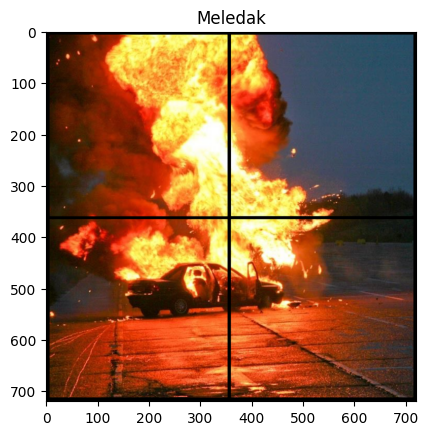

In [62]:
Citra1 = plt.imread("Assets/Meledak.png")

plt.title('Meledak')
plt.imshow(Citra1)

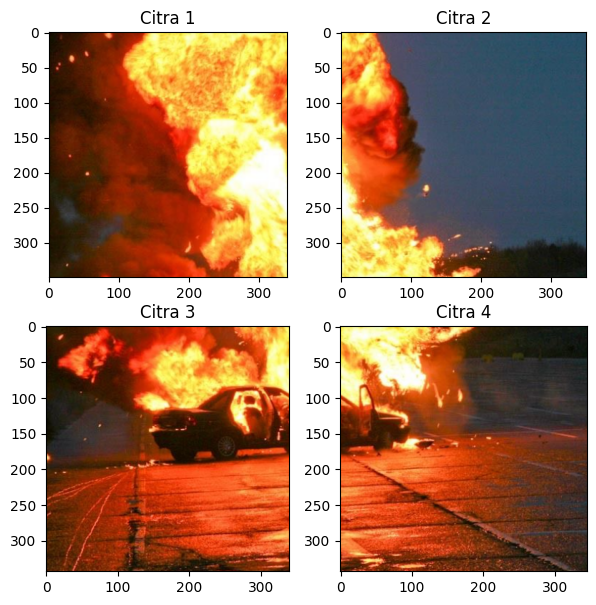

In [83]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

p1_h = slice(Citra1, 10, 360, mode='H')
p1_slice = slice(p1_h, 10, 350, mode='V')

p2_h = slice(Citra1, 10, 360, mode='H')
p2_slice = slice(p2_h, 360, 710, mode='V')

p3_h = slice(Citra1, 367, 710, mode='H')
p3_slice = slice(p3_h, 10, 350, mode='V')

p4_h = slice(Citra1, 367, 710, mode='H')
p4_slice = slice(p4_h, 365, 710, mode='V')

plt.figure(figsize=(7, 7))
plt.subplot(2, 2, 1)
plt.imshow(p1_slice, cmap='gray')
plt.title("Citra 1")


plt.subplot(2, 2, 2)
plt.imshow(p2_slice, cmap='gray')
plt.title("Citra 2")

plt.subplot(2, 2, 3)
plt.imshow(p3_slice, cmap='gray')
plt.title("Citra 3")

plt.subplot(2, 2, 4)
plt.imshow(p4_slice, cmap='gray')
plt.title("Citra 4")

plt.show()

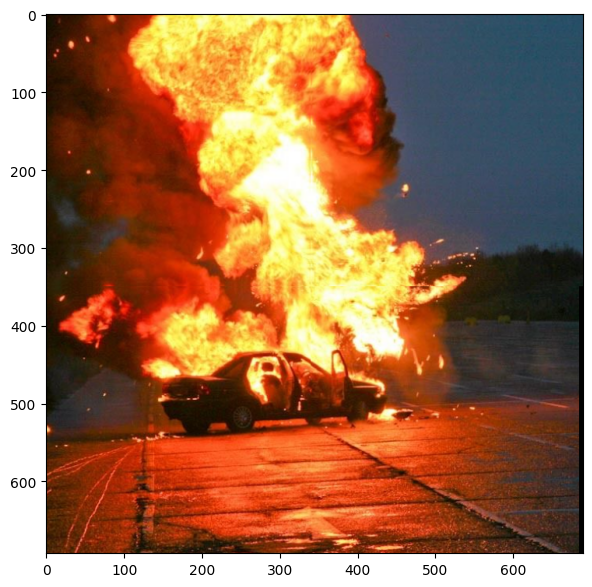

In [82]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], 
citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 
0:citra2.shape[1]] = citra2 
     
    return gabungan

plt.figure(figsize=(7, 7))
merge1 = merge_image(p1_slice, p2_slice, orientation='H')
merge2 = merge_image(p3_slice, p4_slice, orientation='H')
hasil1 = merge_image(merge1, merge2, orientation='V')

plt.imshow(hasil1)
plt.show()

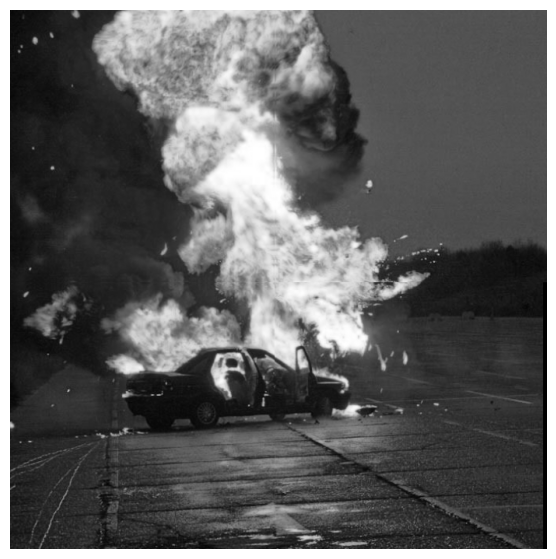

In [81]:
hasil1_gray = cv2.cvtColor(hasil1, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(7, 7))
plt.imshow(hasil1_gray, cmap='gray')
plt.axis('off')
plt.show()

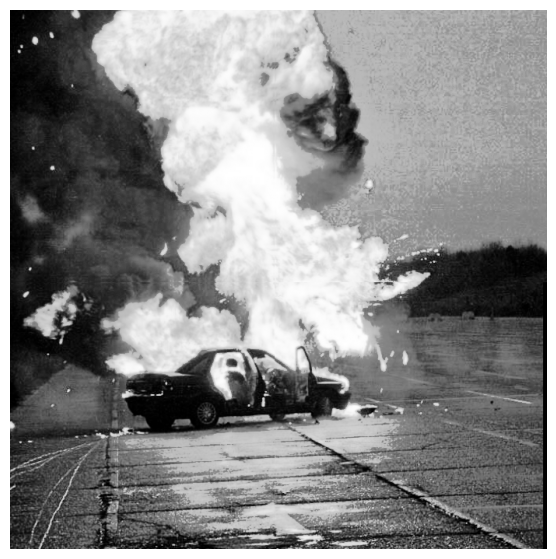

In [80]:
def ekualisasi(citra):
    height, width = citra.shape

    hist = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

hasil_ekualisasi = ekualisasi((hasil1_gray * 255).astype(np.uint8))
plt.figure(figsize=(7, 7))
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.axis('off')
plt.show()

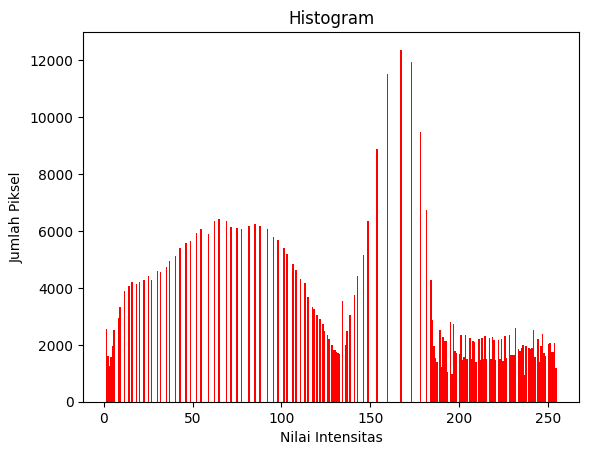

In [88]:
plt.hist(hasil_ekualisasi.ravel(), bins=300, color='red')
plt.title("Histogram")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

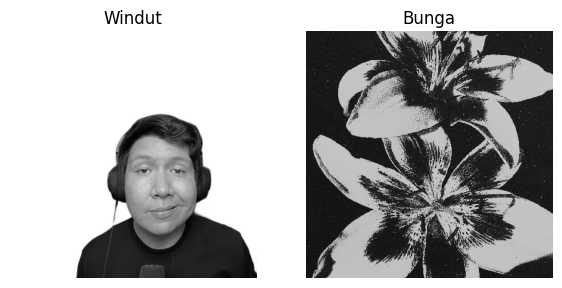

In [91]:
Windut = plt.imread("Assets/Windut.png")
Bunga = plt.imread("Assets/Bunga.png")

Windut_gray = cv2.cvtColor(Windut, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(7, 7))
plt.subplot(1, 2, 1)
plt.imshow(Windut_gray, cmap='gray')
plt.title('Windut')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(Bunga)
plt.title('Bunga')
plt.axis('off')

plt.show()

In [ ]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
# tambah kode perulangan untuk hitung histogram citra asal 
# lakukan iterasi setiap pixel di citra asal, lalu tambahkan 
1 pada index hist_asal sesuai nilai pixelnya 
 
 # tambah kode perulangan untuk hitung histogram citra target 
# lakukan hal yang sama seperti di citra asal, tapi ini untuk 
citra_target dan hist_target 
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
# tambah kode perulangan untuk hitung CDF,hitung nilai CDF dari index 1 sampai 255. 
#setiap nilai CDF diperoleh dari penjumlahan nilai CDF  
(CDF_asal dan CDF_target) sebelumnya dengan nilai histogram 
(hist_awal dan hist_target) saat ini  
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
#tambah kode buat perulangan mapping histogramnya 
#untuk setiap nilai pixel I pada citra_asal, cari nilai j pada citra_target yang memiliki selisih CDF paling kecil terhadap CDF_asal 
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
#tambah kode perulangan untuk menerapkan hasil mapping ke 
citra asal, gunakan nilai pixel citra_asal sebagai index 
untuk mengambil nilai dari map_hist 
 
 
    return hasil 
 
#cara manggil: spesifikasi1 = 
spesifikasi_histogram(citra_asal_kalian, citra_target_kalian)

In [ ]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i, j]] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i, j]] += 1

    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i-1] + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        diff = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(diff)

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

hasil_spesifikasi = spesifikasi_histogram((Windut_gray * 255).astype(np.uint8), (Bunga_gray * 255).astype(np.uint8))
plt.figure(figsize=(7, 7))
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')
plt.show()
plt.figure(figsize=(7, 7))
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')
plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices